In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import pairwise_distances

# Change Working Dir To the Project Working Dir (for Noam)

In [2]:
import ipynbname
# change the dir to the grandparent directory of the current working directory

note_dir = ipynbname.path().parent
grandparent_dir = note_dir.parent.parent
os.chdir(grandparent_dir)
print(os.getcwd())  # Check the cwd has updated

c:\Users\noams\Python Projects\Audio_processing_project


# Classical Clustering

## Naive Clustering

In [3]:
raw_data = pd.read_csv(Path(r"CREMA-D\TCAV\with-test Tcav-per-sample cremaD.csv"))

In [4]:
raw_data

,path,concept name,layer name,positive percentage,magnitude,cav acc,true label,predicted label,predicted probability
0,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-constant-thick,module3.blocks.0.conv2,1.0,0.622,0.957,neutral,neutral,0.999
1,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-dropping-flat-thick,module3.blocks.0.conv2,0.0,-1.364,0.870,neutral,neutral,0.999
2,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-dropping-steep-thick,module3.blocks.0.conv2,1.0,0.132,0.783,neutral,neutral,0.999
3,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-dropping-steep-thin,module3.blocks.0.conv2,0.0,-0.601,0.913,neutral,neutral,0.999
4,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-rising-flat-thick,module3.blocks.0.conv2,1.0,0.970,0.696,neutral,neutral,0.999
...,...,...,...,...,...,...,...,...,...
89299,CREMA-D\DATASETS\splitted data\train\1020_TAI_...,short-constant-thick,module3.blocks.0.conv2,0.0,-0.319,0.826,neutral,neutral,1.000
89300,CREMA-D\DATASETS\splitted data\train\1020_TAI_...,short-dropping-steep-thick,module3.blocks.0.conv2,0.0,-0.172,0.739,neutral,neutral,1.000
89301,CREMA-D\DATASETS\splitted data\train\1020_TAI_...,short-dropping-steep-thin,module3.blocks.0.conv2,0.0,-0.359,0.826,neutral,neutral,1.000
89302,CREMA-D\DATASETS\splitted data\train\1020_TAI_...,short-rising-steep-thick,module3.blocks.0.conv2,0.0,-0.237,0.957,neutral,neutral,1.000


In [5]:
data_matching_predictions = raw_data[raw_data["true label"] == raw_data["predicted label"]]

In [6]:
data_matching_predictions

,path,concept name,layer name,positive percentage,magnitude,cav acc,true label,predicted label,predicted probability
0,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-constant-thick,module3.blocks.0.conv2,1.0,0.622,0.957,neutral,neutral,0.999
1,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-dropping-flat-thick,module3.blocks.0.conv2,0.0,-1.364,0.870,neutral,neutral,0.999
2,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-dropping-steep-thick,module3.blocks.0.conv2,1.0,0.132,0.783,neutral,neutral,0.999
3,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-dropping-steep-thin,module3.blocks.0.conv2,0.0,-0.601,0.913,neutral,neutral,0.999
4,CREMA-D\DATASETS\splitted data\train\1071_TSI_...,long-rising-flat-thick,module3.blocks.0.conv2,1.0,0.970,0.696,neutral,neutral,0.999
...,...,...,...,...,...,...,...,...,...
89299,CREMA-D\DATASETS\splitted data\train\1020_TAI_...,short-constant-thick,module3.blocks.0.conv2,0.0,-0.319,0.826,neutral,neutral,1.000
89300,CREMA-D\DATASETS\splitted data\train\1020_TAI_...,short-dropping-steep-thick,module3.blocks.0.conv2,0.0,-0.172,0.739,neutral,neutral,1.000
89301,CREMA-D\DATASETS\splitted data\train\1020_TAI_...,short-dropping-steep-thin,module3.blocks.0.conv2,0.0,-0.359,0.826,neutral,neutral,1.000
89302,CREMA-D\DATASETS\splitted data\train\1020_TAI_...,short-rising-steep-thick,module3.blocks.0.conv2,0.0,-0.237,0.957,neutral,neutral,1.000


In [7]:
vector_df_glob = data_matching_predictions.pivot_table(
    index=["path", "true label"],   # rows by recordingo
    columns="concept name",      # each concept becomes its own column
    values="magnitude"          # the numeric values go in
).reset_index(drop = False)

In [8]:
vector_df_glob

concept name,path,true label,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
0,CREMA-D\DATASETS\splitted data\test\1001_DFA_H...,happy,0.723,-0.230,0.923,0.572,0.761,0.578,1.150,0.617,0.476,0.231,1.088,1.522
1,CREMA-D\DATASETS\splitted data\test\1001_IEO_A...,angry,-0.409,0.275,0.409,-0.257,0.007,-0.882,-0.372,-0.641,-0.356,-0.132,-0.317,-0.589
2,CREMA-D\DATASETS\splitted data\test\1001_IEO_A...,angry,-0.666,-0.501,0.125,-0.546,-0.223,-0.997,-0.691,-0.401,-0.346,-0.209,-0.646,-0.219
3,CREMA-D\DATASETS\splitted data\test\1001_IEO_D...,disgusted,-2.226,-1.805,-0.927,-2.119,-1.007,-2.097,-1.630,-1.371,-0.824,-1.107,-2.270,-1.262
4,CREMA-D\DATASETS\splitted data\test\1001_IOM_H...,happy,0.623,-0.217,0.087,0.526,0.365,0.675,0.226,0.816,0.061,0.000,0.463,0.909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6585,CREMA-D\DATASETS\splitted data\val\1091_MTI_NE...,neutral,-0.047,-1.796,-0.613,-1.737,0.439,-1.274,-0.685,-1.560,-1.028,-0.990,-0.981,-0.885
6586,CREMA-D\DATASETS\splitted data\val\1091_TAI_NE...,neutral,-0.679,-0.244,-0.494,-0.987,-0.276,-0.615,-0.646,-1.181,-0.267,-0.141,-0.451,-0.930
6587,CREMA-D\DATASETS\splitted data\val\1091_TAI_SA...,sad,-1.671,-0.971,-1.277,-1.727,-1.508,-1.251,-1.473,-0.980,-0.319,-0.206,-1.673,-1.294
6588,CREMA-D\DATASETS\splitted data\val\1091_TIE_HA...,happy,0.616,0.591,0.217,0.903,-0.076,0.753,0.352,0.919,0.178,0.668,0.402,0.415


## Label-concept table

In [9]:
vector_df_glob.drop(columns=['path']).groupby("true label").mean().reset_index().round(3)

concept name,true label,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
0,angry,-0.459,-0.509,0.077,-0.600,0.263,-0.639,0.099,-0.445,-0.005,-0.568,-0.095,0.034
1,disgusted,-1.639,-1.659,-1.108,-1.908,-0.977,-1.824,-1.601,-1.194,-0.872,-1.051,-2.042,-1.226
2,fearful,0.711,0.671,0.553,0.768,0.684,0.781,1.031,0.461,0.582,0.102,1.064,0.746
3,happy,1.182,0.113,0.266,0.801,0.490,0.854,0.466,0.692,0.090,0.394,0.704,0.647
4,neutral,0.089,-0.495,-0.148,-0.527,0.134,-0.358,-0.333,-0.587,-0.477,-0.134,-0.280,-0.390
5,sad,-0.180,-0.128,-0.494,-0.202,-0.490,-0.066,-0.647,-0.119,-0.350,0.155,-0.597,-0.565


In [10]:
# Features (X) and labels (y)
X = vector_df_glob.drop(columns=["path", "true label"], inplace=False).to_numpy()
y = vector_df_glob["true label"].to_numpy()

In [11]:
X.shape, y.shape

((6590, 12), (6590,))

In [12]:
# added by Noam as KMeans has a known bug when on Windows using MKL with multithreading.
import os
os.environ["OMP_NUM_THREADS"] = "6"
# end of addition

In [13]:
def intra_inter_scores(X, y, metric="euclidean", float_precision=3):
    """Compute intra- and inter-cluster distance statistics for labels y using the given metric.

    Returns:
      - intra_mean: mean of within-class pairwise distances
      - inter_mean: mean of between-class pairwise distances
      - separation: inter_mean / intra_mean
    """
    # 1) Compute pairwise distance matrix for the chosen metric
    dist_matrix = pairwise_distances(X, metric=metric)
    # 2) Unique label identifiers present in y
    labels = np.unique(y)

    # 3) Accumulators for intra- and inter-class distances
    intra_dists = []
    inter_dists = []

    # 4) Intra-class distances: average of upper triangle (exclude diagonal)
    for label in labels:
        idx = np.where(y == label)[0]
        if len(idx) > 1:
            d = dist_matrix[np.ix_(idx, idx)]
            intra_dists.append(d[np.triu_indices_from(d, k=1)].mean())

    # 5) Inter-class distances: mean distances across class pairs
    for i, lbl1 in enumerate(labels):
        for lbl2 in labels[i+1:]:
            idx1 = np.where(y == lbl1)[0]
            idx2 = np.where(y == lbl2)[0]
            d = dist_matrix[np.ix_(idx1, idx2)]
            inter_dists.append(d.mean())

    # 6) Aggregate metrics
    return {
        "intra mean": round(np.mean(intra_dists), float_precision),
        "inter mean": round(np.mean(inter_dists), float_precision),
        "separation": round(np.mean(inter_dists) / np.mean(intra_dists), float_precision)
    }

In [14]:
from sklearn.preprocessing import normalize


def evaluate_clustering(X, y, n_clusters, random_state=42, print_results=True, return_results=False, float_precision=3):
    # KMeans clustering with Euclidean distance
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    clusters_euc = kmeans.fit_predict(X)
    
    # KMeans clustering with Cosine distance
    X_cosine = normalize(X, norm='l2', axis=1)        # put points on the unit sphere
    clusters_cos = kmeans.fit_predict(X_cosine)
    
    if print_results:
        # ---- STEP 4: Evaluation (since you have ground truth labels) ----
        print("Euclidean clustering ARI:", round(adjusted_rand_score(y, clusters_euc), float_precision))
        print("Cosine clustering ARI:", round(adjusted_rand_score(y, clusters_cos), float_precision))
        print("Euclidean Silhouette:", round(silhouette_score(X, clusters_euc), float_precision))
        print("Cosine Silhouette:", round(silhouette_score(X_cosine, clusters_cos), float_precision))

        # Intra-cluster and inter-cluster scores
        print("Euclidean:", intra_inter_scores(X, clusters_euc, metric="euclidean", float_precision=float_precision))
        print("Cosine:", intra_inter_scores(X, clusters_cos, metric="cosine", float_precision=float_precision))

    if return_results:
        return {
                    "Euclidean clustering ARI": round(adjusted_rand_score(y, clusters_euc), float_precision),
                    "Cosine clustering ARI": round(adjusted_rand_score(y, clusters_cos), float_precision),
                    "Euclidean Silhouette": round(silhouette_score(X, clusters_euc), float_precision),
                    "Cosine Silhouette": round(silhouette_score(X_cosine, clusters_cos), float_precision),
                    "Euclidean": intra_inter_scores(X, clusters_euc, metric="euclidean", float_precision=float_precision),
                    "Cosine": intra_inter_scores(X, clusters_cos, metric="cosine", float_precision=float_precision)
                }

## Hyperparameter Evaluation of Naive Clustering

In [15]:
evaluate_clustering(X, y, n_clusters=4, print_results=True)

Euclidean clustering ARI: 0.183
Cosine clustering ARI: 0.212
Euclidean Silhouette: 0.302
Cosine Silhouette: 0.397
Euclidean: {'intra mean': 2.213, 'inter mean': 5.482, 'separation': 2.477}
Cosine: {'intra mean': 0.394, 'inter mean': 1.165, 'separation': 2.956}


In [16]:
evaluate_clustering(X, y, n_clusters=5, print_results=True)

Euclidean clustering ARI: 0.164
Cosine clustering ARI: 0.214
Euclidean Silhouette: 0.258
Cosine Silhouette: 0.298
Euclidean: {'intra mean': 2.081, 'inter mean': 5.533, 'separation': 2.659}
Cosine: {'intra mean': 0.351, 'inter mean': 1.137, 'separation': 3.237}


In [17]:
evaluate_clustering(X, y, n_clusters=6, print_results=True)

Euclidean clustering ARI: 0.214
Cosine clustering ARI: 0.22
Euclidean Silhouette: 0.249
Cosine Silhouette: 0.303
Euclidean: {'intra mean': 1.985, 'inter mean': 5.113, 'separation': 2.576}
Cosine: {'intra mean': 0.337, 'inter mean': 1.089, 'separation': 3.232}


In [18]:
evaluate_clustering(X, y, n_clusters=8, print_results=True)

Euclidean clustering ARI: 0.188
Cosine clustering ARI: 0.267
Euclidean Silhouette: 0.211
Cosine Silhouette: 0.288
Euclidean: {'intra mean': 1.857, 'inter mean': 5.33, 'separation': 2.871}
Cosine: {'intra mean': 0.307, 'inter mean': 1.064, 'separation': 3.463}


In [19]:
cluster_dict = {num:evaluate_clustering(X, y, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

{2: {'Euclidean clustering ARI': 0.137,
  'Cosine clustering ARI': 0.14,
  'Euclidean Silhouette': 0.424,
  'Cosine Silhouette': 0.5,
  'Euclidean': {'intra mean': 2.929, 'inter mean': 5.43, 'separation': 1.854},
  'Cosine': {'intra mean': 0.434, 'inter mean': 1.534, 'separation': 3.531}},
 3: {'Euclidean clustering ARI': 0.205,
  'Cosine clustering ARI': 0.188,
  'Euclidean Silhouette': 0.369,
  'Cosine Silhouette': 0.399,
  'Euclidean': {'intra mean': 2.445, 'inter mean': 5.642, 'separation': 2.308},
  'Cosine': {'intra mean': 0.399, 'inter mean': 1.209, 'separation': 3.033}},
 4: {'Euclidean clustering ARI': 0.183,
  'Cosine clustering ARI': 0.212,
  'Euclidean Silhouette': 0.302,
  'Cosine Silhouette': 0.397,
  'Euclidean': {'intra mean': 2.213, 'inter mean': 5.482, 'separation': 2.477},
  'Cosine': {'intra mean': 0.394, 'inter mean': 1.165, 'separation': 2.956}},
 5: {'Euclidean clustering ARI': 0.164,
  'Cosine clustering ARI': 0.214,
  'Euclidean Silhouette': 0.258,
  'Cosine Si

In [27]:
# Features (X) and labels (y)
vector_df_glob_fix = vector_df_glob.copy()
# remove happy and neutral
# vector_df_glob_fix = vector_df_glob_fix[vector_df_glob_fix["true label"] != "happy" ]
# vector_df_glob_fix = vector_df_glob_fix[vector_df_glob_fix["true label"] != "neutral" ]
vector_df_glob_fix
X_w_h_n = vector_df_glob_fix.drop(columns=["path", "true label"], inplace=False).to_numpy()
y_w_h_n = vector_df_glob_fix["true label"].to_numpy()

In [28]:
cluster_dict = {num:evaluate_clustering(X_w_h_n, y_w_h_n, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

{2: {'Euclidean clustering ARI': 0.137,
  'Cosine clustering ARI': 0.14,
  'Euclidean Silhouette': 0.424,
  'Cosine Silhouette': 0.5,
  'Euclidean': {'intra mean': 2.929, 'inter mean': 5.43, 'separation': 1.854},
  'Cosine': {'intra mean': 0.434, 'inter mean': 1.534, 'separation': 3.531}},
 3: {'Euclidean clustering ARI': 0.205,
  'Cosine clustering ARI': 0.188,
  'Euclidean Silhouette': 0.369,
  'Cosine Silhouette': 0.399,
  'Euclidean': {'intra mean': 2.445, 'inter mean': 5.642, 'separation': 2.308},
  'Cosine': {'intra mean': 0.399, 'inter mean': 1.209, 'separation': 3.033}},
 4: {'Euclidean clustering ARI': 0.183,
  'Cosine clustering ARI': 0.212,
  'Euclidean Silhouette': 0.302,
  'Cosine Silhouette': 0.397,
  'Euclidean': {'intra mean': 2.213, 'inter mean': 5.482, 'separation': 2.477},
  'Cosine': {'intra mean': 0.394, 'inter mean': 1.165, 'separation': 2.956}},
 5: {'Euclidean clustering ARI': 0.164,
  'Cosine clustering ARI': 0.214,
  'Euclidean Silhouette': 0.258,
  'Cosine Si

In [29]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"
df.reset_index(inplace=True)


display(df)

,num clusters,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra mean,Euclidean inter mean,Euclidean separation,Cosine intra mean,Cosine inter mean,Cosine separation
0,2,0.137,0.140,0.424,0.500,2.929,5.430,1.854,0.434,1.534,3.531
1,3,0.205,0.188,0.369,0.399,2.445,5.642,2.308,0.399,1.209,3.033
2,4,0.183,0.212,0.302,0.397,2.213,5.482,2.477,0.394,1.165,2.956
3,5,0.164,0.214,0.258,0.298,2.081,5.533,2.659,0.351,1.137,3.237
4,6,0.214,0.220,0.249,0.303,1.985,5.113,2.576,0.337,1.089,3.232
5,7,0.192,0.246,0.228,0.275,1.907,5.284,2.770,0.315,1.071,3.403
6,8,0.188,0.267,0.211,0.288,1.857,5.330,2.871,0.307,1.064,3.463
7,9,0.188,0.278,0.205,0.226,1.807,5.135,2.843,0.290,1.054,3.633
8,10,0.185,0.278,0.199,0.201,1.765,5.070,2.873,0.279,1.051,3.765


In [30]:
df[["num clusters", 'Cosine Silhouette']]

,num clusters,Cosine Silhouette
0,2,0.500
1,3,0.399
2,4,0.397
3,5,0.298
4,6,0.303
5,7,0.275
6,8,0.288
7,9,0.226
8,10,0.201


In [16]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"

display(df)

,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra mean,Euclidean inter mean,Euclidean separation,Cosine intra mean,Cosine inter mean,Cosine separation
num clusters,,,,,,,,,,
2,0.137,0.140,0.424,0.500,2.929,5.430,1.854,0.434,1.534,3.531
3,0.205,0.188,0.369,0.399,2.445,5.642,2.308,0.399,1.209,3.033
4,0.183,0.212,0.302,0.397,2.213,5.482,2.477,0.394,1.165,2.956
5,0.164,0.214,0.258,0.298,2.081,5.533,2.659,0.351,1.137,3.237
6,0.214,0.220,0.249,0.303,1.985,5.113,2.576,0.337,1.089,3.232
7,0.192,0.246,0.228,0.275,1.907,5.284,2.770,0.315,1.071,3.403
8,0.188,0.267,0.211,0.288,1.857,5.330,2.871,0.307,1.064,3.463
9,0.188,0.278,0.205,0.226,1.807,5.135,2.843,0.290,1.054,3.633
10,0.185,0.278,0.199,0.201,1.765,5.070,2.873,0.279,1.051,3.765


## Clustering with good CAVs only

In [21]:
######### filter all bad CAVs #########

# load tcav_per_sample_with_acc.csv
acc_df = pd.read_csv(Path(r"CREMA-D\TCAV\with-test Tcav-per-sample cremaD.csv"))
acc_df.groupby("concept name")["cav acc"].mean()

# mask with only 85% and up remaining true
high_acc_concepts = acc_df[acc_df["cav acc"] >= 0.85]["concept name"].unique()
high_acc_concepts

array(['long-constant-thick', 'long-dropping-flat-thick',
       'long-dropping-steep-thin', 'long-rising-steep-thick',
       'short-rising-steep-thick'], dtype=object)

In [22]:
# drop from vector_df any columns not in high_acc_concepts
vector_df_high_acc = vector_df_glob[["path", "true label"] + list(high_acc_concepts)]
vector_df_high_acc

concept name,path,true label,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thin,long-rising-steep-thick,short-rising-steep-thick
0,CREMA-D\DATASETS\splitted data\test\1001_DFA_H...,happy,0.723,-0.230,0.572,0.578,1.088
1,CREMA-D\DATASETS\splitted data\test\1001_IEO_A...,angry,-0.409,0.275,-0.257,-0.882,-0.317
2,CREMA-D\DATASETS\splitted data\test\1001_IEO_A...,angry,-0.666,-0.501,-0.546,-0.997,-0.646
3,CREMA-D\DATASETS\splitted data\test\1001_IEO_D...,disgusted,-2.226,-1.805,-2.119,-2.097,-2.270
4,CREMA-D\DATASETS\splitted data\test\1001_IOM_H...,happy,0.623,-0.217,0.526,0.675,0.463
...,...,...,...,...,...,...,...
6585,CREMA-D\DATASETS\splitted data\val\1091_MTI_NE...,neutral,-0.047,-1.796,-1.737,-1.274,-0.981
6586,CREMA-D\DATASETS\splitted data\val\1091_TAI_NE...,neutral,-0.679,-0.244,-0.987,-0.615,-0.451
6587,CREMA-D\DATASETS\splitted data\val\1091_TAI_SA...,sad,-1.671,-0.971,-1.727,-1.251,-1.673
6588,CREMA-D\DATASETS\splitted data\val\1091_TIE_HA...,happy,0.616,0.591,0.903,0.753,0.402


In [23]:
# Features (X) and labels (y)
X = vector_df_high_acc.drop(columns=["path", "true label"], inplace=False).to_numpy()
y = vector_df_high_acc["true label"].to_numpy()

In [24]:
evaluate_clustering(X, y, n_clusters=len(set(y)), print_results=True)

Euclidean clustering ARI: 0.144
Cosine clustering ARI: 0.202
Euclidean Silhouette: 0.306
Cosine Silhouette: 0.39
Euclidean: {'intra mean': 1.238, 'inter mean': 4.305, 'separation': 3.478}
Cosine: {'intra mean': 0.287, 'inter mean': 1.109, 'separation': 3.859}


In [25]:
cluster_dict = {num:evaluate_clustering(X, y, n_clusters=num, return_results=True, print_results=False) for num in range(2, 11)}
cluster_dict

{2: {'Euclidean clustering ARI': 0.135,
  'Cosine clustering ARI': 0.137,
  'Euclidean Silhouette': 0.475,
  'Cosine Silhouette': 0.599,
  'Euclidean': {'intra mean': 2.053, 'inter mean': 4.204, 'separation': 2.048},
  'Cosine': {'intra mean': 0.324, 'inter mean': 1.644, 'separation': 5.067}},
 3: {'Euclidean clustering ARI': 0.187,
  'Cosine clustering ARI': 0.154,
  'Euclidean Silhouette': 0.43,
  'Cosine Silhouette': 0.506,
  'Euclidean': {'intra mean': 1.644, 'inter mean': 4.365, 'separation': 2.654},
  'Cosine': {'intra mean': 0.335, 'inter mean': 1.227, 'separation': 3.662}},
 4: {'Euclidean clustering ARI': 0.173,
  'Cosine clustering ARI': 0.164,
  'Euclidean Silhouette': 0.375,
  'Cosine Silhouette': 0.504,
  'Euclidean': {'intra mean': 1.432, 'inter mean': 4.253, 'separation': 2.969},
  'Cosine': {'intra mean': 0.358, 'inter mean': 1.186, 'separation': 3.31}},
 5: {'Euclidean clustering ARI': 0.159,
  'Cosine clustering ARI': 0.188,
  'Euclidean Silhouette': 0.331,
  'Cosine 

In [26]:
# Flatten sub-dicts
flattened = {}
for k, v in cluster_dict.items():
    row = {}
    for sub_k, sub_v in v.items():
        if isinstance(sub_v, dict):
            for inner_k, inner_v in sub_v.items():
                row[f"{sub_k} {inner_k}"] = inner_v
        else:
            row[sub_k] = sub_v
    flattened[k] = row

# Build DataFrame
df = pd.DataFrame.from_dict(flattened, orient="index")
df.index.name = "num clusters"

display(df)

,Euclidean clustering ARI,Cosine clustering ARI,Euclidean Silhouette,Cosine Silhouette,Euclidean intra mean,Euclidean inter mean,Euclidean separation,Cosine intra mean,Cosine inter mean,Cosine separation
num clusters,,,,,,,,,,
2,0.135,0.137,0.475,0.599,2.053,4.204,2.048,0.324,1.644,5.067
3,0.187,0.154,0.430,0.506,1.644,4.365,2.654,0.335,1.227,3.662
4,0.173,0.164,0.375,0.504,1.432,4.253,2.969,0.358,1.186,3.310
5,0.159,0.188,0.331,0.412,1.316,4.241,3.222,0.308,1.136,3.688
6,0.144,0.202,0.306,0.390,1.238,4.305,3.478,0.287,1.109,3.859
7,0.141,0.241,0.272,0.289,1.182,4.314,3.650,0.260,1.087,4.173
8,0.132,0.191,0.252,0.260,1.130,4.285,3.791,0.237,1.083,4.569
9,0.139,0.265,0.243,0.253,1.094,4.038,3.690,0.227,1.062,4.673
10,0.147,0.272,0.235,0.298,1.070,3.957,3.698,0.222,1.060,4.771


## with features normalized

In [27]:
from sklearn.preprocessing import StandardScaler, normalize

# Features (X) and labels (y)
X = vector_df_glob.drop(columns=["path", "true label"], inplace=False).to_numpy()
y = vector_df_glob["true label"].to_numpy()

X_std = StandardScaler().fit_transform(X)   # z-score per feature

In [28]:
evaluate_clustering(X_std, y, n_clusters=len(set(y)), print_results=True)

Euclidean clustering ARI: 0.219
Cosine clustering ARI: 0.281
Euclidean Silhouette: 0.238
Cosine Silhouette: 0.276
Euclidean: {'intra mean': 2.156, 'inter mean': 5.253, 'separation': 2.437}
Cosine: {'intra mean': 0.359, 'inter mean': 1.125, 'separation': 3.132}


# PCA on CAVs

In [16]:
# PCA: compute 2D and 3D projections of X
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# drop the rows with happy/neutral labels
vector_df_glob_for_pca = vector_df_glob#[~vector_df_glob["true label"].isin(["happy", "neutral"])]

X = vector_df_glob_for_pca.drop(columns=["path", "true label"], inplace=False).to_numpy()

# Fit PCA for 2 and 3 components
pca2 = PCA(n_components=2)
pca3 = PCA(n_components=3)

X_pca2 = pca2.fit_transform(X)
X_pca3 = pca3.fit_transform(X)

evr2 = pca2.explained_variance_ratio_
evr3 = pca3.explained_variance_ratio_

print("2D PCA explained variance ratio:", np.round(evr2, 4), " (sum =", round(evr2.sum(), 4), ")")
print("3D PCA explained variance ratio:", np.round(evr3, 4), " (sum =", round(evr3.sum(), 4), ")")

2D PCA explained variance ratio: [0.8533 0.0724]  (sum = 0.9257 )
3D PCA explained variance ratio: [0.8533 0.0724 0.0293]  (sum = 0.9549 )


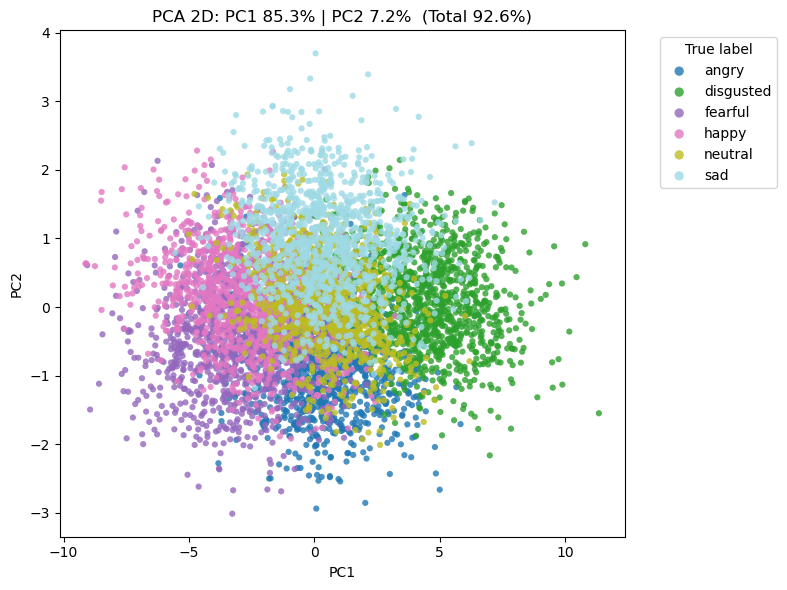

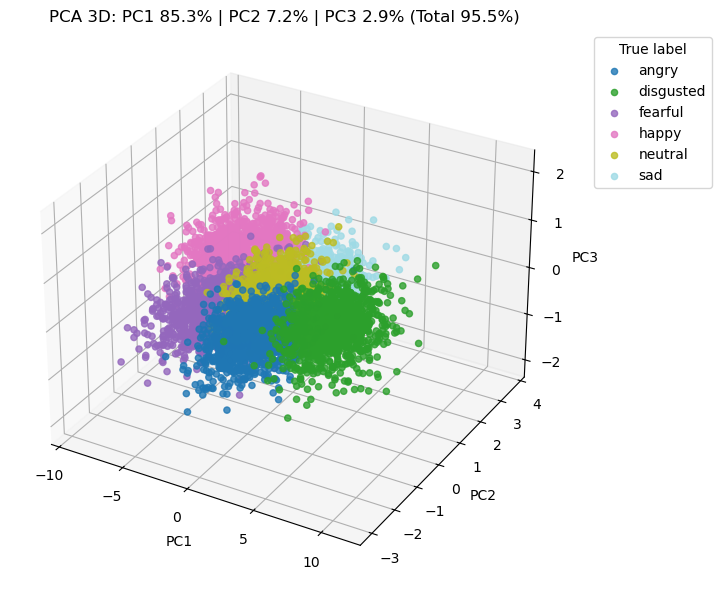

In [17]:
# Plot the PCA results (2D and 3D)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from PreprocessParams import LABEL_STRINGS

y = vector_df_glob_for_pca["true label"].to_numpy()

labels = np.unique(y)

# Get the continuous colormap
cmap = mpl.colormaps.get_cmap("tab20")

# Sample exactly len(labels) colors
colors = cmap(np.linspace(0, 1, len(labels)))

# 2D scatter
plt.figure(figsize=(8, 6))
for i, lbl in enumerate(labels):
    
    lbl_idxs = (y == lbl)
    plt.scatter(
        X_pca2[lbl_idxs, 0], X_pca2[lbl_idxs, 1],
        s=20, alpha=0.8, color=colors[i], label=f"{lbl}", edgecolors="none"
    )
    
title2 = f"PCA 2D: PC1 {evr2[0]*100:.1f}% | PC2 {evr2[1]*100:.1f}%  (Total {evr2.sum()*100:.1f}%)"
plt.title(title2)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="True label", markerscale=1.5, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3D scatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
for i, lbl in enumerate(labels):
    idx = (y == lbl)
    ax.scatter(
        X_pca3[idx, 0], X_pca3[idx, 1], X_pca3[idx, 2],
        s=20, alpha=0.8, color=colors[i], label=f"{lbl}"
    )
title3 = (
    f"PCA 3D: PC1 {evr3[0]*100:.1f}% | PC2 {evr3[1]*100:.1f}% | PC3 {evr3[2]*100:.1f}% "
    f"(Total {evr3.sum()*100:.1f}%)"
)
ax.set_title(title3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(title="True label", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## labels distribution accross clusters + Centroids

In [18]:
from tcav_demo import CONCEPT_UNIQUE_NAMES

def get_label_distribution_fitted(X, y, clustering_model, random_state=42, print_results=False):
    
    cluster_labels = clustering_model.predict(X)

    # Create a DataFrame to hold the cluster labels and true labels
    df = pd.DataFrame({'cluster': cluster_labels, 'true_label': y})

    # Get the distribution of clusters per true label
    label_distribution = df.groupby('true_label')['cluster'].value_counts(normalize=True).unstack(fill_value=0)

    #// # modify true_label to be the actual label names instead of numbers using LABEL_EMOTION_MAPPING
    
    #// label_distribution.index = label_distribution.index.map(label_mapping)
    
    # add cluster suffix to each column name
    label_distribution.columns = [f"{col} clus" for col in label_distribution.columns]
    
    # Create DataFrame for centroids
    centroids_df = pd.DataFrame(
        clustering_model.cluster_centers_,
        index=[f"cluster_{i}" for i in range(clustering_model.cluster_centers_.shape[0])],
        columns=[f"{concept}" for concept in CONCEPT_UNIQUE_NAMES]
    )

    if print_results:
        print("Cluster distribution across labels:")
        print(label_distribution)
        print("\nCluster centroids:")
        print(centroids_df)

    return label_distribution, centroids_df

def get_label_distribution_unfitted(X, y, clustering_model, random_state=42, print_results=False):
    clustering_model.fit(X)
    return get_label_distribution_fitted(X, y, clustering_model, random_state, print_results)

#? Example usage:
lbl_dist, cent_df = get_label_distribution_unfitted(X, y, KMeans(n_clusters=4, random_state=42), print_results=False)
display(lbl_dist)
display(cent_df)

,0 clus,1 clus,2 clus,3 clus
true_label,,,,
angry,0.056228,0.401384,0.497405,0.044983
disgusted,0.776786,0.006250,0.216071,0.000893
fearful,0.000000,0.386740,0.057090,0.556169
happy,0.000882,0.430335,0.100529,0.468254
neutral,0.043165,0.386434,0.543679,0.026721
sad,0.092774,0.403211,0.463872,0.040143


,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
cluster_0,-1.707619,-1.896123,-1.226799,-2.086659,-0.976210,-1.993825,-1.751985,-1.280857,-1.017289,-1.190697,-2.228104,-1.324928
cluster_1,0.367811,0.070642,0.122422,0.187502,0.259409,0.244518,0.225715,0.073594,0.032955,0.079952,0.293527,0.160626
cluster_2,-0.471415,-0.785371,-0.420958,-0.810239,-0.180250,-0.718057,-0.587440,-0.548893,-0.448966,-0.460610,-0.729404,-0.478966
cluster_3,1.296251,1.022818,0.772119,1.331208,0.749548,1.351409,1.207919,0.855229,0.668337,0.653150,1.488788,0.999395


In [19]:
from pprint import pprint
from sklearn.preprocessing import normalize

X = vector_df_glob.drop(columns=["path", "true label"], inplace=False).to_numpy()
y = vector_df_glob["true label"].to_numpy()

# normalize X
X = normalize(X, norm='l2', axis=1)        # put points on the unit sphere

lbl_dist, cent_df = get_label_distribution_unfitted(X, y, KMeans(n_clusters=5, random_state=42), print_results=False)
display(lbl_dist)
display(cent_df)

,0 clus,1 clus,2 clus,3 clus,4 clus
true_label,,,,,
angry,0.339100,0.217128,0.396194,0.012976,0.034602
disgusted,0.988393,0.000893,0.000893,0.008929,0.000893
fearful,0.033149,0.441989,0.079190,0.024862,0.420810
happy,0.050265,0.125220,0.096120,0.063492,0.664903
neutral,0.483042,0.059609,0.173690,0.144913,0.138746
sad,0.472792,0.010705,0.019625,0.328278,0.168599


,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
cluster_0,-0.244157,-0.315814,-0.205728,-0.347152,-0.135247,-0.313461,-0.289713,-0.231070,-0.191411,-0.182143,-0.354359,-0.236089
cluster_1,0.200245,0.078659,0.241833,0.142371,0.295801,0.135715,0.402177,0.093502,0.207888,-0.030516,0.362068,0.319173
cluster_2,-0.075124,-0.391696,0.038214,-0.323563,0.219345,-0.286583,0.103600,-0.211603,-0.027146,-0.303145,-0.009003,0.099942
cluster_3,0.134348,0.126406,-0.191807,0.080622,-0.148372,0.152595,-0.291938,-0.051596,-0.226934,0.203553,-0.149789,-0.324333
cluster_4,0.380469,0.242955,0.133810,0.342938,0.159123,0.366407,0.202649,0.201821,0.077834,0.203955,0.315241,0.167557


## Create centroids per label

In [20]:
# for each label, compute its centroid all in a df
centroids_per_label = {}
for label in np.unique(y):
    label_idxs = np.where(y == label)[0]
    if len(label_idxs) > 0:
        centroids_per_label[label] = X[label_idxs].mean(axis=0)

centroids_df = pd.DataFrame(centroids_per_label).T
# centroids_df.index = centroids_df.index.map(label_mapping) # no need, since we already have the actual labels
# for each column, set the name to be the concept name
centroids_df.columns = [f"{concept}" for concept in CONCEPT_UNIQUE_NAMES]
centroids_df

,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
angry,-0.195290,-0.189185,0.071814,-0.244716,0.150483,-0.265777,0.090927,-0.199000,0.022786,-0.244941,0.014114,0.039414
disgusted,-0.316516,-0.300015,-0.205892,-0.357607,-0.194312,-0.342131,-0.303708,-0.229219,-0.159385,-0.189848,-0.385980,-0.237445
fearful,0.211966,0.183684,0.146286,0.212054,0.237951,0.218454,0.319626,0.117529,0.166247,-0.029372,0.306544,0.212521
happy,0.419514,-0.051474,0.054658,0.236052,0.173681,0.261337,0.120450,0.230307,-0.012932,0.098293,0.194046,0.215155
neutral,0.099481,-0.190279,-0.032693,-0.214708,0.093940,-0.125251,-0.125289,-0.281735,-0.221910,-0.015600,-0.075302,-0.172302
sad,-0.040562,-0.012477,-0.200210,-0.047619,-0.206910,0.022967,-0.245781,-0.028714,-0.126086,0.110731,-0.219377,-0.226477


In [21]:
import numpy as np
import pandas as pd

class CentroidClassifier:
    """
    Classify by nearest centroid computed beforehand.
    centroids_df: DataFrame with index=emotion names, columns=concepts, values=centroid coords.
    metric: 'euclidean' | 'cosine' | 'manhattan'
    temperature: softmax temperature for predict_proba (smaller = sharper).
    """
    def __init__(self, centroids_df: pd.DataFrame, metric: str = "cosine", temperature: float = 1.0):
        self.metric = metric
        self.tau = float(temperature)
        self.labels_ = centroids_df.index.to_numpy()
        self.columns_ = centroids_df.columns
        self.cluster_centers_ = centroids_df.to_numpy(dtype=float)  # (n_centroids, d)

    def _to_array(self, X):
        # Accepts np.ndarray or DataFrame; if DF, align columns to centroids
        if isinstance(X, pd.DataFrame):
            missing = set(self.columns_) - set(X.columns)
            if missing:
                raise ValueError(f"X is missing columns: {sorted(missing)}")
            X = X.loc[:, self.columns_].to_numpy(dtype=float)
        else:
            X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X[None, :]
        return X

    def _distances(self, X):
        X = self._to_array(X)  # (n, d)
        if self.metric == "euclidean":
            d = np.sqrt(((X[:, None, :] - self.cluster_centers_[None, :, :]) ** 2).sum(axis=2))
        elif self.metric == "manhattan":
            d = np.abs(X[:, None, :] - self.cluster_centers_[None, :, :]).sum(axis=2)
        elif self.metric == "cosine":
            eps = 1e-12
            Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
            Cn = self.cluster_centers_ / (np.linalg.norm(self.cluster_centers_, axis=1, keepdims=True) + eps)
            d = 1.0 - Xn @ Cn.T
        else:
            raise ValueError(f"Unsupported metric: {self.metric}")
        return d  # shape (n_samples, n_centroids)

    def predict(self, X):
        d = self._distances(X)
        return self.labels_[d.argmin(axis=1)]

    def decision_function(self, X):
        # Higher is better (negative distance)
        return -self._distances(X)

    def predict_proba(self, X):
        # Softmax over negative distances (temperature = tau)
        s = self.decision_function(X) / self.tau
        s -= s.max(axis=1, keepdims=True)
        e = np.exp(s)
        return e / e.sum(axis=1, keepdims=True)  # shape (n_samples, n_centroids)

In [22]:
# Build classifier from your centroids
clf = CentroidClassifier(centroids_df, metric="cosine", temperature=0.5)

# Classify new samples in the same concept space (numpy array or DataFrame with same columns)
y_pred_names = clf.predict(X)              # array of emotion names (centroid labels)
probas = clf.predict_proba(X)              # soft assignment to each emotion (columns=centroids_df.index)

# If you need numeric IDs back (inverse of LABEL_EMOTION_MAPPING):
# name_to_id = {v: k for k, v in label_mapping.items()}
# y_pred_ids = np.vectorize(name_to_id.get)(y_pred_names)

In [23]:
# evaluate clustering on centroids_df using
# ---- STEP 4: Evaluation (since you have ground truth labels) ----
print("ARI:", adjusted_rand_score(y, y_pred_names))
print("Silhouette:", silhouette_score(X, y_pred_names))

# Intra-cluster and inter-cluster scores
print(intra_inter_scores(X, y_pred_names, metric="euclidean"))

ARI: 0.2988111170246161
Silhouette: 0.2650783697519841
{'intra mean': 0.761, 'inter mean': 1.416, 'separation': 1.86}


In [27]:
from pprint import pprint
from sklearn.preprocessing import normalize

X = vector_df_glob.drop(columns=["path", "true label"], inplace=False).to_numpy()
y = vector_df_glob["true label"].to_numpy()

# normalize X
X = normalize(X, norm='l2', axis=1)        # put points on the unit sphere

lbl_dist, cent_df = get_label_distribution_fitted(X, y, clf, print_results=False)
display(lbl_dist)
display(cent_df)

,angry clus,disgusted clus,fearful clus,happy clus,neutral clus,sad clus
true_label,,,,,,
angry,0.440311,0.307958,0.224048,0.002595,0.017301,0.007785
disgusted,0.001786,0.978571,0.000893,0.000000,0.000893,0.017857
fearful,0.069982,0.031308,0.825046,0.046041,0.013812,0.013812
happy,0.021164,0.041446,0.223104,0.621693,0.067019,0.025573
neutral,0.076053,0.314491,0.136691,0.081192,0.334018,0.057554
sad,0.009813,0.354148,0.093666,0.115968,0.013381,0.413024


,long-constant-thick,long-dropping-flat-thick,long-dropping-steep-thick,long-dropping-steep-thin,long-rising-flat-thick,long-rising-steep-thick,long-rising-steep-thin,short-constant-thick,short-dropping-steep-thick,short-dropping-steep-thin,short-rising-steep-thick,short-rising-steep-thin
cluster_0,-0.195290,-0.189185,0.071814,-0.244716,0.150483,-0.265777,0.090927,-0.199000,0.022786,-0.244941,0.014114,0.039414
cluster_1,-0.316516,-0.300015,-0.205892,-0.357607,-0.194312,-0.342131,-0.303708,-0.229219,-0.159385,-0.189848,-0.385980,-0.237445
cluster_2,0.211966,0.183684,0.146286,0.212054,0.237951,0.218454,0.319626,0.117529,0.166247,-0.029372,0.306544,0.212521
cluster_3,0.419514,-0.051474,0.054658,0.236052,0.173681,0.261337,0.120450,0.230307,-0.012932,0.098293,0.194046,0.215155
cluster_4,0.099481,-0.190279,-0.032693,-0.214708,0.093940,-0.125251,-0.125289,-0.281735,-0.221910,-0.015600,-0.075302,-0.172302
cluster_5,-0.040562,-0.012477,-0.200210,-0.047619,-0.206910,0.022967,-0.245781,-0.028714,-0.126086,0.110731,-0.219377,-0.226477
